# Sentiment Analysis of Financial News Using Machine Learning
### 7058EFA — Artificial Intelligence in FinTech | April 2026

This notebook benchmarks three classical ML classifiers against FinBERT on the Financial PhraseBank (Malo et al., 2014) for three-class sentiment classification (positive / neutral / negative). The trained SVM is then deployed in a FinTech trading signal simulator and validated against 53,650 unseen headlines from Reuters, CNBC, and the Guardian.

**Full pipeline:**
1. Data loading, preprocessing, and TF-IDF vectorisation
2. Exploratory data analysis
3. Classical model training: Logistic Regression, Naive Bayes, SVM
4. FinBERT inference (transformer, fourth model — academic comparison)
5. Four-model performance comparison
6. Feature importance — SVM coefficient weights
7. FinTech trading signal simulator (SVM)
8. Cross-dataset validation — Reuters, CNBC, Guardian
9. Reuters temporal split — pre-2019 vs 2019+ (SVM + FinBERT)
10. Extended evaluation — cross-validation, bootstrap CIs, ROC, PR, learning curves
Appendix Cell: TextBlob polarity analysis (supplementary)

## Cell 1 — Imports, Data Loading, and Preprocessing

Loads the full Financial PhraseBank from `all-data.csv` — 4,846 sentences across all annotator agreement levels. Text goes through four sequential transformations before TF-IDF vectorisation: lowercasing and noise removal → tokenisation → stopword removal → lemmatisation.

The raw headline split is preserved separately — FinBERT in Cell 4 needs the original text, not the cleaned version.

In [ ]:
# CELL 1: IMPORTS, DATA LOADING, AND PREPROCESSING
# Financial PhraseBank source: https://www.kaggle.com/datasets/ankurzing/sentiment-analysis-for-financial-news
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, f1_score, precision_score, recall_score
)

nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',  quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Load Financial PhraseBank (all agreement configurations, all-data.csv)
# 4,846 sentences across all annotator agreement levels
df = pd.read_csv('/content/all-data.csv',
                 names=['Sentiment', 'Headline'],
                 encoding='latin-1')

print(f'Dataset loaded: {len(df):,} records')
print(f'Class distribution:\n{df["Sentiment"].value_counts()}')
print(f'Class proportions:\n{df["Sentiment"].value_counts(normalize=True).round(3)}')

# Preprocessing function -- used for classical ML only
# NOTE: FinBERT (Cell 4) uses raw text -- do NOT apply clean_text to FinBERT inputs
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

df['Cleaned_Headline'] = df['Headline'].apply(clean_text)

# TF-IDF vectorisation (5,000 features)
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['Cleaned_Headline'])
y = df['Sentiment']

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Keep raw headline split aligned -- needed for FinBERT in Cell 4
df_reset = df.reset_index(drop=True)
_, df_test = train_test_split(
    df_reset, test_size=0.2, random_state=42, stratify=df_reset['Sentiment']
)
df_test = df_test.reset_index(drop=True)

print(f'\nTraining samples : {X_train.shape[0]:,}')
print(f'Testing samples  : {X_test.shape[0]:,}')
print('Preprocessing complete.')


Dataset loaded: 4,846 records
Class distribution:
Sentiment
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64
Class proportions:
Sentiment
neutral     0.594
positive    0.281
negative    0.125
Name: proportion, dtype: float64

Training samples : 3,876
Testing samples  : 970
Preprocessing complete.


## Cell 2 — Exploratory Data Analysis

Class distribution across all the agreement PhraseBank: Neutral dominates at ~59%, Positive at ~28%, Negative at ~13%. This imbalance mirrors real financial news, directional signals are the minority and is why F1-Score is the primary evaluation metric rather than raw accuracy.

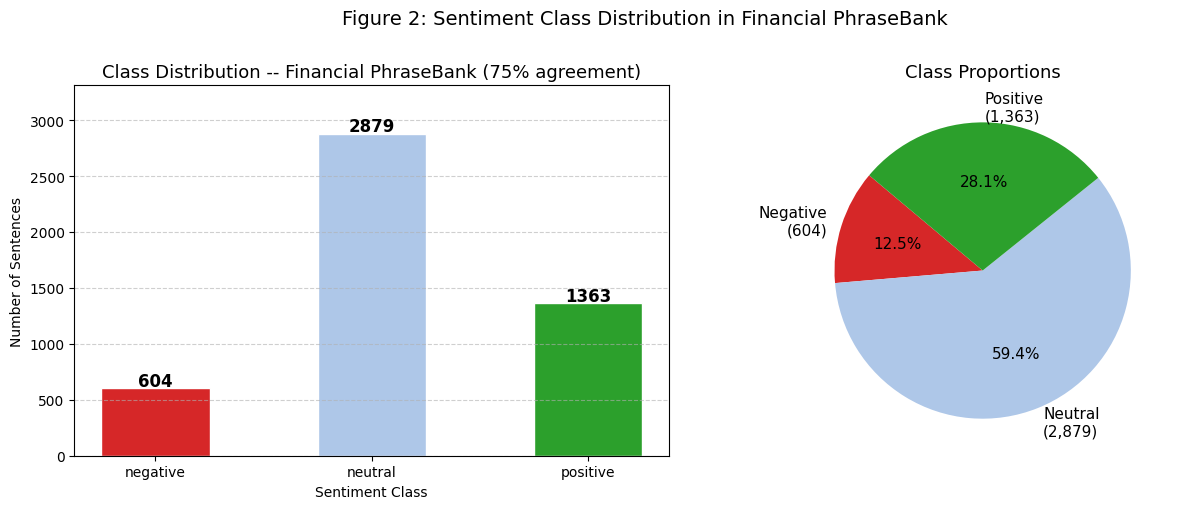


Sentence length statistics by class:
            count   mean    std  min   25%   50%   75%   max
Sentiment                                                   
negative    604.0  23.92   9.89  5.0  17.0  22.0  30.0  56.0
neutral    2879.0  22.18   9.82  2.0  15.0  21.0  28.0  81.0
positive   1363.0  24.69  10.06  5.0  17.0  23.0  31.0  57.0

Overall average sentence length: 23.1 words


In [ ]:
# CELL 2: EXPLORATORY DATA ANALYSIS
class_counts = df['Sentiment'].value_counts()[['negative', 'neutral', 'positive']]
colours_eda  = ['#d62728', '#aec7e8', '#2ca02c']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(class_counts.index, class_counts.values, color=colours_eda, edgecolor='white', width=0.5)
for i, (label, val) in enumerate(zip(class_counts.index, class_counts.values)):
    axes[0].text(i, val + 20, str(val), ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Class Distribution -- Financial PhraseBank (all agreement levels/all-data.csv)', fontsize=13)
axes[0].set_xlabel('Sentiment Class')
axes[0].set_ylabel('Number of Sentences')
axes[0].set_ylim(0, max(class_counts.values) * 1.15)
axes[0].yaxis.grid(True, linestyle='--', alpha=0.6)

axes[1].pie(
    class_counts.values,
    labels=[f'{l.capitalize()}\n({v:,})' for l, v in zip(class_counts.index, class_counts.values)],
    colors=colours_eda, autopct='%1.1f%%', startangle=140,
    textprops={'fontsize': 11}
)
axes[1].set_title('Class Proportions', fontsize=13)

plt.suptitle('Figure 2: Sentiment Class Distribution in Financial PhraseBank', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

df['word_count'] = df['Headline'].apply(lambda x: len(str(x).split()))
print('\nSentence length statistics by class:')
print(df.groupby('Sentiment')['word_count'].describe().round(2))
print(f'\nOverall average sentence length: {df["word_count"].mean():.1f} words')


## Cell 3 — Classical Model Training and Confusion Matrices

Three classifiers trained on the TF-IDF feature matrix (5,000 features, stratified 80/20 split):
- **Logistic Regression** — interpretable linear baseline; coefficients are directly inspectable for regulatory auditability
- **Multinomial Naive Bayes** — probabilistic, high throughput, but assumes feature independence
- **SVM (linear kernel)** — strong theoretical fit for high-dimensional sparse text; margin maximisation in TF-IDF space

Per-class confusion matrices are saved for inclusion in the report.


  Training: Logistic Regression
Accuracy            : 0.7320 (73.20%)
Precision (weighted): 0.7295
Recall    (weighted): 0.7320
F1-Score  (weighted): 0.7112

Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.43      0.54       121
     neutral       0.74      0.93      0.82       576
    positive       0.71      0.45      0.55       273

    accuracy                           0.73       970
   macro avg       0.73      0.60      0.64       970
weighted avg       0.73      0.73      0.71       970



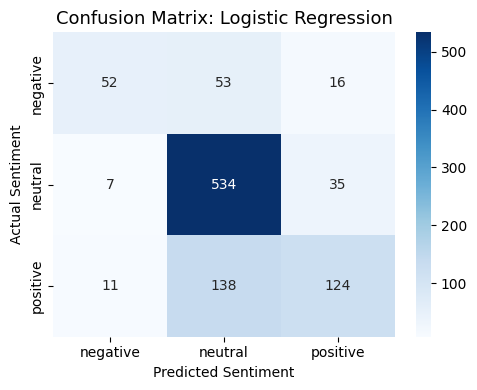


  Training: Naive Bayes
Accuracy            : 0.6928 (69.28%)
Precision (weighted): 0.7181
Recall    (weighted): 0.6928
F1-Score  (weighted): 0.6373

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      0.07      0.14       121
     neutral       0.71      0.96      0.81       576
    positive       0.62      0.40      0.49       273

    accuracy                           0.69       970
   macro avg       0.78      0.48      0.48       970
weighted avg       0.72      0.69      0.64       970



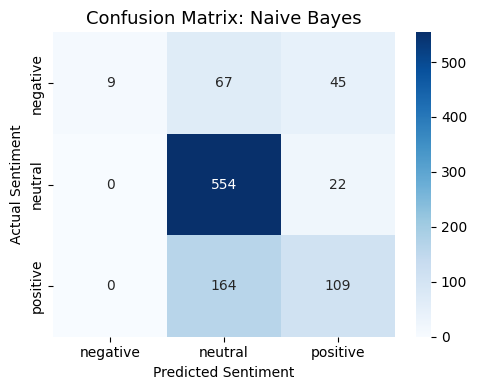


  Training: Support Vector Machine (SVM)
Accuracy            : 0.7320 (73.20%)
Precision (weighted): 0.7229
Recall    (weighted): 0.7320
F1-Score  (weighted): 0.7196

Classification Report:
              precision    recall  f1-score   support

    negative       0.65      0.50      0.57       121
     neutral       0.76      0.89      0.82       576
    positive       0.68      0.50      0.58       273

    accuracy                           0.73       970
   macro avg       0.70      0.63      0.65       970
weighted avg       0.72      0.73      0.72       970



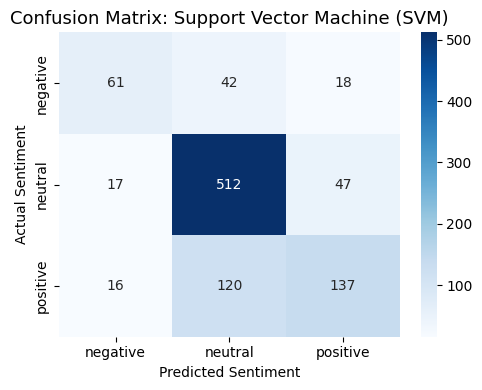


All classical models trained and evaluated.


In [ ]:
# CELL 3: CLASSICAL MODEL TRAINING AND CONFUSION MATRICES

classical_models = {
    'Logistic Regression':         LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes':                  MultinomialNB(),
    'Support Vector Machine (SVM)': SVC(kernel='linear', random_state=42)
}

# results stores metrics for ALL models (classical + FinBERT added in Cell 4)
results = {}
class_order = ['negative', 'neutral', 'positive']

for name, model in classical_models.items():
    print(f'\n{"="*60}')
    print(f'  Training: {name}')
    print(f'{"="*60}')

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted', zero_division=0)
    rec  = recall_score(y_test, preds, average='weighted', zero_division=0)
    f1   = f1_score(y_test, preds, average='weighted', zero_division=0)

    results[name] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'preds': preds}

    print(f'Accuracy            : {acc:.4f} ({acc*100:.2f}%)')
    print(f'Precision (weighted): {prec:.4f}')
    print(f'Recall    (weighted): {rec:.4f}')
    print(f'F1-Score  (weighted): {f1:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_test, preds, target_names=class_order, zero_division=0))

    cm = confusion_matrix(y_test, preds, labels=class_order)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_order, yticklabels=class_order)
    plt.title(f'Confusion Matrix: {name}', fontsize=13)
    plt.ylabel('Actual Sentiment')
    plt.xlabel('Predicted Sentiment')
    plt.tight_layout()
    safe_name = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f'confusion_matrix_{safe_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Store SVM reference for feature importance and simulator cells
svm_model = classical_models['Support Vector Machine (SVM)']

print('\nAll classical models trained and evaluated.')


## Cell 4 — FinBERT Evaluation (Fourth Model)

FinBERT (Araci, 2019 — `ProsusAI/finbert`) is a BERT-based model fine-tuned on the Financial PhraseBank for 3-class sentiment classification. It runs on the same 970-sentence test set as the classical models for a direct like-for-like comparison.

**Key differences from the classical models:**
- Takes raw text directly — its internal tokeniser handles punctuation and casing, so cleaned text is not passed in
- Labels output as `positive`, `negative`, `neutral` — already matching the class names used throughout
- Included for academic benchmarking only; the SVM handles the trading simulator (Cell 7) due to real-time speed and regulatory interpretability requirements

**Runtime note:** CPU inference on 970 sentences takes 10–20 minutes. Switch to T4 GPU (Runtime → Change runtime type) for ~3 minutes.

Libraries installed.
Device: GPU (CUDA)
Loading ProsusAI/finbert from HuggingFace Hub...
(First run downloads ~700MB -- subsequent runs use cache)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

FinBERT loaded. Running inference on 970 test sentences...
(10-20 min on CPU / ~3 min on GPU)

  Processed 160/970 sentences...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Processed 320/970 sentences...
  Processed 480/970 sentences...
  Processed 640/970 sentences...
  Processed 800/970 sentences...
  Processed 960/970 sentences...
  Processed 970/970 sentences...

  FinBERT Results
Accuracy            : 0.8722 (87.22%)
Precision (weighted): 0.8844
Recall    (weighted): 0.8722
F1-Score  (weighted): 0.8737

Classification Report:
              precision    recall  f1-score   support

    negative       0.76      0.97      0.85       121
     neutral       0.95      0.84      0.89       576
    positive       0.79      0.90      0.84       273

    accuracy                           0.87       970
   macro avg       0.84      0.90      0.86       970
weighted avg       0.88      0.87      0.87       970



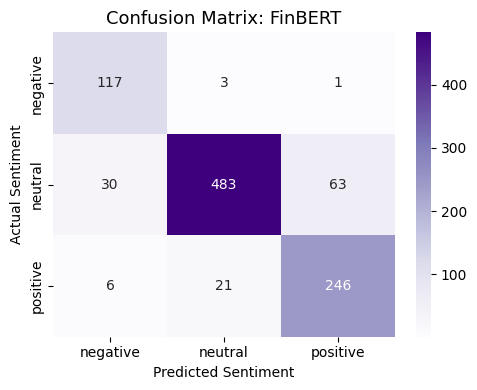


FinBERT evaluation complete. Results stored in results["FinBERT"].


In [ ]:
# CELL 4: FINBERT EVALUATION -- FOURTH MODEL
# Model: ProsusAI/finbert (Araci, 2019)
# BERT fine-tuned on the Financial PhraseBank for 3-class sentiment classification.

# Step 1: Install transformers (only once per Colab session)
import subprocess
subprocess.run(['pip', 'install', 'transformers', 'torch', '-q'], check=True)
print('Libraries installed.')

from transformers import pipeline
import torch

print(f'Device: {"GPU (CUDA)" if torch.cuda.is_available() else "CPU"}')
print('Loading ProsusAI/finbert from HuggingFace Hub...')
print('(First run downloads ~700MB -- subsequent runs use cache)\n')

# Step 2: Load the FinBERT pipeline
finbert_pipe = pipeline(
    task='text-classification',
    model='ProsusAI/finbert',
    tokenizer='ProsusAI/finbert',
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=512
)

print('FinBERT loaded. Running inference on 970 test sentences...')
print('(10-20 min on CPU / ~3 min on GPU)\n')

# Step 3: Inference on raw test headlines (df_test created in Cell 1)
raw_test_headlines = df_test['Headline'].tolist()
true_labels        = df_test['Sentiment'].tolist()

# Process in batches of 32 to avoid memory issues
batch_size = 32
finbert_raw_preds = []

for start in range(0, len(raw_test_headlines), batch_size):
    batch = raw_test_headlines[start:start + batch_size]
    batch_results = finbert_pipe(batch)
    finbert_raw_preds.extend(batch_results)
    processed = min(start + batch_size, len(raw_test_headlines))
    if processed % 160 == 0 or processed == len(raw_test_headlines):
        print(f'  Processed {processed}/{len(raw_test_headlines)} sentences...')

# Step 4: Extract labels -- FinBERT outputs lowercase positive/negative/neutral
finbert_preds = [r['label'].lower() for r in finbert_raw_preds]

# Step 5: Compute metrics (same framework as classical models in Cell 3)
acc  = accuracy_score(true_labels, finbert_preds)
prec = precision_score(true_labels, finbert_preds, average='weighted', zero_division=0)
rec  = recall_score(true_labels, finbert_preds, average='weighted', zero_division=0)
f1   = f1_score(true_labels, finbert_preds, average='weighted', zero_division=0)

results['FinBERT'] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'preds': finbert_preds}

print(f'\n{"="*60}')
print(f'  FinBERT Results')
print(f'{"="*60}')
print(f'Accuracy            : {acc:.4f} ({acc*100:.2f}%)')
print(f'Precision (weighted): {prec:.4f}')
print(f'Recall    (weighted): {rec:.4f}')
print(f'F1-Score  (weighted): {f1:.4f}')
print('\nClassification Report:')
print(classification_report(true_labels, finbert_preds, target_names=class_order, zero_division=0))

# Step 6: Confusion matrix
cm_fb = confusion_matrix(true_labels, finbert_preds, labels=class_order)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_fb, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_order, yticklabels=class_order)
plt.title('Confusion Matrix: FinBERT', fontsize=13)
plt.ylabel('Actual Sentiment')
plt.xlabel('Predicted Sentiment')
plt.tight_layout()
plt.savefig('confusion_matrix_finbert.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFinBERT evaluation complete. Results stored in results["FinBERT"].')


## Cell 5 — Combined Model Performance Comparison (All Four Models)

Pulls metrics from the `results` dict populated across Cells 3 and 4. A vertical dashed line on the chart separates the classical models from the transformer to make the trade-off between performance and interpretability visually explicit.

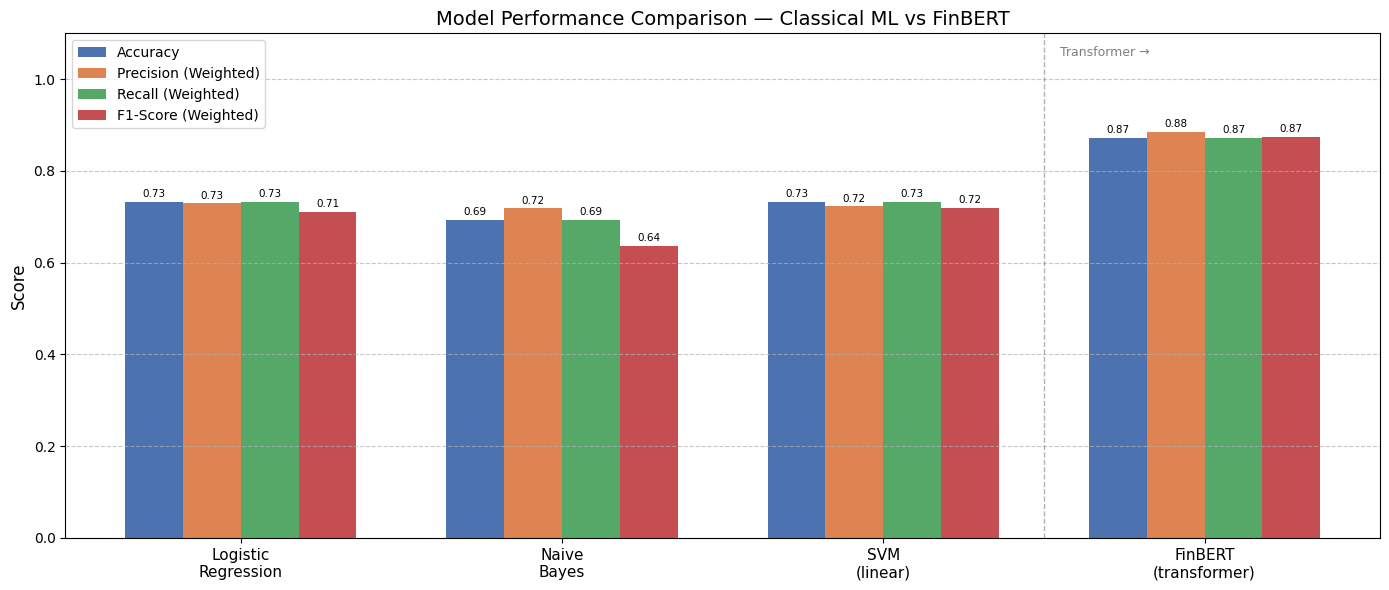


=== Table 1: Summary of All Model Performance ===
Model                                 Accuracy   Precision   Recall       F1
---------------------------------------------------------------------------
Logistic Regression                     73.20%       0.73     0.73     0.71
Naive Bayes                             69.28%       0.72     0.69     0.64
SVM (linear)                            73.20%       0.72     0.73     0.72
FinBERT                                 87.22%       0.88     0.87     0.87


In [ ]:
# CELL 5: COMBINED MODEL PERFORMANCE COMPARISON -- ALL FOUR MODELS
# results dict contains all four models from Cells 3 and 4

all_model_keys = [
    'Logistic Regression',
    'Naive Bayes',
    'Support Vector Machine (SVM)',
    'FinBERT'
]

display_names = [
    'Logistic\nRegression',
    'Naive\nBayes',
    'SVM\n(linear)',
    'FinBERT\n(transformer)'
]

accs  = [results[k]['accuracy']  for k in all_model_keys]
precs = [results[k]['precision'] for k in all_model_keys]
recs  = [results[k]['recall']    for k in all_model_keys]
f1s   = [results[k]['f1']        for k in all_model_keys]

x     = np.arange(len(display_names))
width = 0.18

fig, ax = plt.subplots(figsize=(14, 6))
bars_acc  = ax.bar(x - 1.5*width, accs,  width, label='Accuracy',            color='#4c72b0')
bars_prec = ax.bar(x - 0.5*width, precs, width, label='Precision (Weighted)', color='#dd8452')
bars_rec  = ax.bar(x + 0.5*width, recs,  width, label='Recall (Weighted)',    color='#55a868')
bars_f1   = ax.bar(x + 1.5*width, f1s,   width, label='F1-Score (Weighted)',  color='#c44e52')

# Value labels on every bar
for bars in [bars_acc, bars_prec, bars_rec, bars_f1]:
    ax.bar_label(bars, fmt='%.2f', fontsize=7.5, padding=2)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison — Classical ML vs FinBERT', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(display_names, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Divider separating classical models from transformer
ax.axvline(x=2.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.text(2.55, 1.05, 'Transformer →', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('model_comparison_all_four.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Table 1: Summary of All Model Performance ===')
print(f'{"Model":<35} {"Accuracy":>10} {"Precision":>11} {"Recall":>8} {"F1":>8}')
print('-' * 75)
labels_short = ['Logistic Regression', 'Naive Bayes', 'SVM (linear)', 'FinBERT']
for k, d_name in zip(all_model_keys, labels_short):
    r = results[k]
    print(f'{d_name:<35} {r["accuracy"]*100:>9.2f}% {r["precision"]:>10.2f}  '
          f'{r["recall"]:>7.2f}  {r["f1"]:>7.2f}')


## Cell 6 — Feature Importance Analysis (SVM Coefficients)

The SVM's linear kernel exposes a coefficient matrix of shape (n_classes × n_features). Plotting the top 15 highest-weighted TF-IDF terms per class confirms the model has learned genuine financial vocabulary — not noise. FinBERT has no equivalent: its representations live inside attention heads, not inspectable sparse weights. That opacity is exactly why the SVM is preferred for the trading simulator from a compliance standpoint.

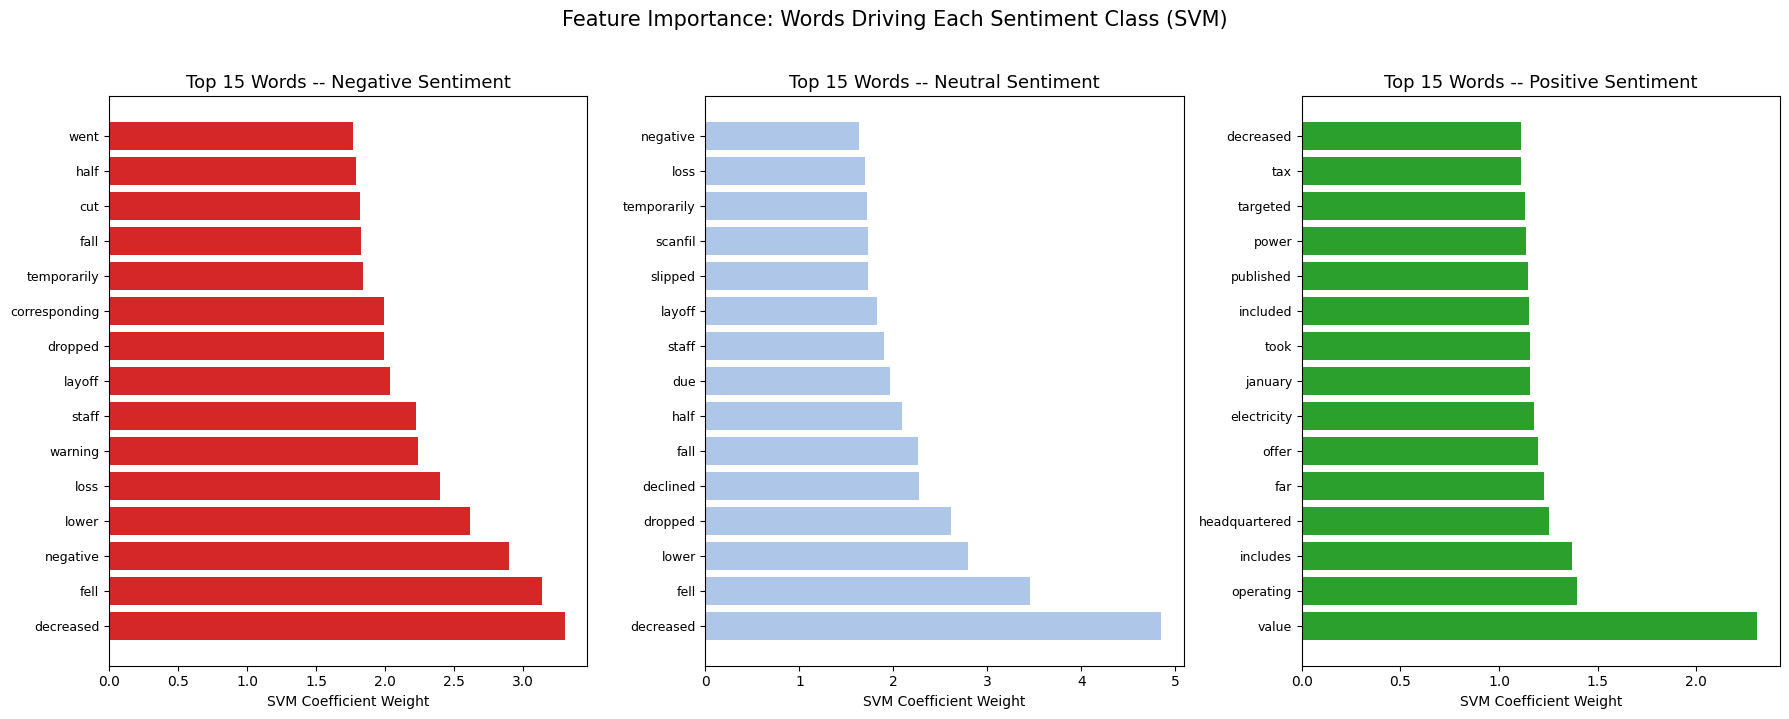

Feature importance chart saved.


In [ ]:
# CELL 6: FEATURE IMPORTANCE -- SVM COEFFICIENT WEIGHTS
feature_names = np.array(tfidf.get_feature_names_out())
coefs = (svm_model.coef_.toarray()
         if hasattr(svm_model.coef_, 'toarray')
         else np.array(svm_model.coef_))

class_labels = ['negative', 'neutral', 'positive']
colours      = ['#d62728', '#aec7e8', '#2ca02c']
top_n        = 15

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for i, (label, colour) in enumerate(zip(class_labels, colours)):
    top_idx   = np.argsort(coefs[i])[-top_n:]
    top_words = feature_names[top_idx]
    top_vals  = coefs[i][top_idx]
    axes[i].barh(top_words, top_vals, color=colour)
    axes[i].set_title(f'Top {top_n} Words -- {label.capitalize()} Sentiment', fontsize=13)
    axes[i].set_xlabel('SVM Coefficient Weight')
    axes[i].tick_params(axis='y', labelsize=9)
    axes[i].invert_yaxis()

plt.suptitle('Feature Importance: Words Driving Each Sentiment Class (SVM)',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance chart saved.')


## Cell 7 — FinTech Trading Signal Simulator (SVM)

Maps the SVM's three sentiment outputs to actionable trading instructions: POSITIVE → BUY, NEGATIVE → SELL, NEUTRAL → HOLD. The SVM's decision function provides a real-valued confidence score alongside each prediction.

FinBERT is not used here for three reasons: it cannot produce signals in real time, its confidence scores are softmax probabilities rather than margin-based distances (less calibrated for threshold-based trading logic), and its black-box nature creates auditability issues under financial regulation. That trade-off is grounded in Mishev et al. (2020) and Karanikola et al. (2023).

In [ ]:
# CELL 7: FINTECH TRADING SIGNAL SIMULATOR — SVM vs FinBERT
# SVM: best classical model — real-time speed, interpretable decision function
# FinBERT: included here to show how the transformer handles the same headlines

def svm_signal(headline):
    cleaned    = clean_text(headline)
    vectorized = tfidf.transform([cleaned])
    sentiment  = svm_model.predict(vectorized)[0]
    confidence = float(np.max(svm_model.decision_function(vectorized)[0]))
    signal_map = {'positive': 'BUY', 'negative': 'SELL', 'neutral': 'HOLD'}
    return sentiment, signal_map[sentiment], round(confidence, 4)

def finbert_signal(headline):
    result    = finbert_pipe([headline])[0]
    sentiment = result['label'].lower()
    confidence = round(result['score'], 4)
    signal_map = {'positive': 'BUY', 'negative': 'SELL', 'neutral': 'HOLD'}
    return sentiment, signal_map[sentiment], confidence

test_headlines = [
    'The company reported record breaking profits and raised its full year guidance.',
    'Operating losses widened significantly as revenues fell short of forecasts.',
    'The board approved the appointment of a new chief financial officer.',
    'Shares surged after the acquisition deal was confirmed by regulators.',
    'The firm announced a major write down following asset impairment charges.',
    'Annual revenue remained flat compared to the previous financial year.'
]

print('=' * 90)
print('   FINTECH TRADING SIGNAL SIMULATOR — SVM vs FinBERT')
print('=' * 90)
print(f'\n{"#":<3} {"SVM":^25} {"FinBERT":^25}  Headline')
print(f'{"":3} {"Sentiment | Signal | Conf":^25} {"Sentiment | Signal | Conf":^25}')
print('-' * 90)

sim_results = []
for i, h in enumerate(test_headlines, 1):
    s_sent, s_sig, s_conf = svm_signal(h)
    f_sent, f_sig, f_conf = finbert_signal(h)
    agree  = '✓' if s_sig == f_sig else '✗'
    svm_str = f'{s_sent.upper():<10} {s_sig:<5} {s_conf:.4f}'
    fb_str  = f'{f_sent.upper():<10} {f_sig:<5} {f_conf:.4f}'
    print(f'{i:<3} {svm_str:<25} {fb_str:<25} {agree}  {h[:55]}')
    sim_results.append({
        'headline': h,
        'svm_sentiment': s_sent, 'svm_signal': s_sig, 'svm_conf': s_conf,
        'fb_sentiment':  f_sent, 'fb_signal':  f_sig, 'fb_conf':  f_conf
    })

print('\n✓ = SVM and FinBERT agree  |  ✗ = models disagree')
agreements = sum(1 for r in sim_results if r['svm_signal'] == r['fb_signal'])
print(f'Agreement on {agreements}/{len(sim_results)} headlines.')

print('\n=== Table 2: Trading Signal Simulator — Summary ===')
print(f'{"#":<3} {"SVM Sentiment":<14} {"SVM Signal":<11} {"SVM Conf":>8}  '
      f'{"FB Sentiment":<14} {"FB Signal":<11} {"FB Conf":>8}')
print('-' * 90)
for i, r in enumerate(sim_results, 1):
    print(f'{i:<3} {r["svm_sentiment"].upper():<14} {r["svm_signal"]:<11} '
          f'{r["svm_conf"]:>8.4f}  {r["fb_sentiment"].upper():<14} '
          f'{r["fb_signal"]:<11} {r["fb_conf"]:>8.4f}')


   FINTECH TRADING SIGNAL SIMULATOR — SVM vs FinBERT

#              SVM                     FinBERT           Headline
    Sentiment | Signal | Conf Sentiment | Signal | Conf
------------------------------------------------------------------------------------------
1   NEUTRAL    HOLD  2.1619   POSITIVE   BUY   0.9532   ✗  The company reported record breaking profits and raised
2   NEGATIVE   SELL  2.2292   NEGATIVE   SELL  0.9747   ✓  Operating losses widened significantly as revenues fell
3   NEUTRAL    HOLD  2.2021   NEUTRAL    HOLD  0.9047   ✓  The board approved the appointment of a new chief finan
4   NEUTRAL    HOLD  2.2013   POSITIVE   BUY   0.8723   ✗  Shares surged after the acquisition deal was confirmed 
5   NEUTRAL    HOLD  2.2497   NEGATIVE   SELL  0.9576   ✗  The firm announced a major write down following asset i
6   NEGATIVE   SELL  2.0549   NEGATIVE   SELL  0.9543   ✓  Annual revenue remained flat compared to the previous f

✓ = SVM and FinBERT agree  |  ✗ = models d

## Cell 8 — Cross-Dataset Validation (Reuters, CNBC, Guardian)

The trained SVM is applied to 53,650 unseen headlines from three professional news sources — no retraining, no fine-tuning. All three CSVs are from the Kaggle dataset: https://www.kaggle.com/datasets/notlucasp/financial-news-headlines

- `reuters_headlines.csv` — 32,770 headlines
- `cnbc_headlines.csv` — 3,080 headlines  
- `guardian_headlines.csv` — 17,800 headlines

Upload all three to `/content/` before running.

reuters_headlines.csv - 32,770 headlines
cnbc_headlines.csv - 3,080 headlines
guardian_headlines.csv - 17,800 headlines

--- RUNNING OUT-OF-SAMPLE PREDICTIONS (SVM) ---

Successfully processed 32,770 headlines from Reuters.
  Negative: 5.3%  |  Neutral: 84.8%  |  Positive: 9.9%
Successfully processed 3,080 headlines from CNBC.
  Negative: 1.6%  |  Neutral: 84.6%  |  Positive: 13.8%
Successfully processed 17,800 headlines from Guardian.
  Negative: 4.8%  |  Neutral: 89.4%  |  Positive: 5.8%


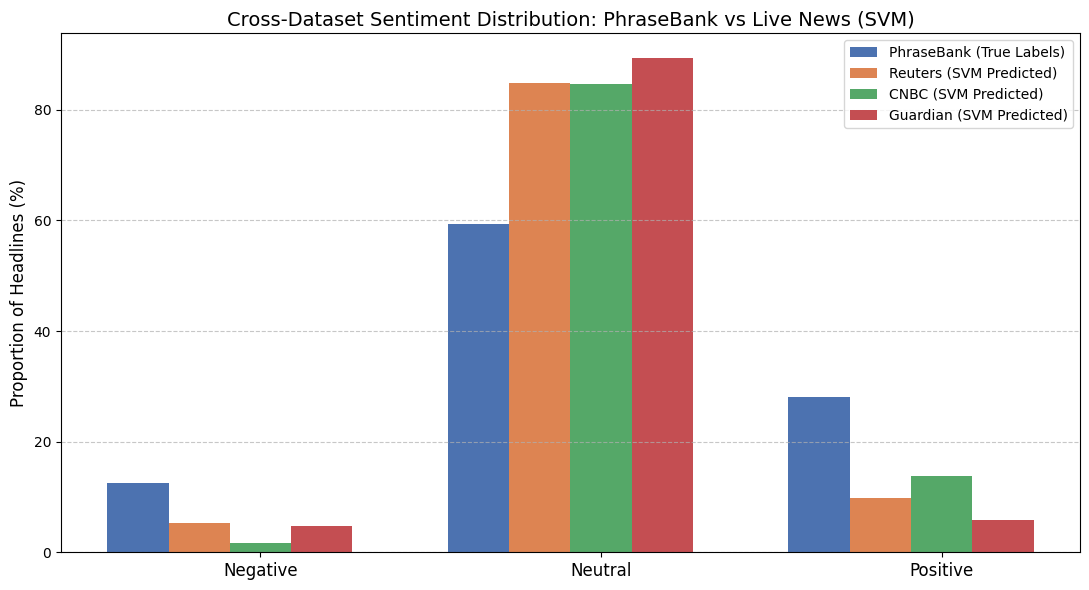

Cross-dataset chart saved.


In [ ]:
# CELL 8: CROSS-DATASET VALIDATION (REUTERS, CNBC, GUARDIAN)
# Source: https://www.kaggle.com/datasets/notlucasp/financial-news-headlines

unseen_datasets = {
    'Reuters':  '/content/reuters_headlines.csv',
    'CNBC':     '/content/cnbc_headlines.csv',
    'Guardian': '/content/guardian_headlines.csv'
}

# A print of the number of headlines to confirm what was written from kaggle in markdown
print(f'reuters_headlines.csv - {len(pd.read_csv(unseen_datasets["Reuters"])):,} headlines')
print(f'cnbc_headlines.csv - {len(pd.read_csv(unseen_datasets['CNBC'])):,} headlines')
print(f'guardian_headlines.csv - {len(pd.read_csv(unseen_datasets['Guardian'])):,} headlines\n')

distribution_results = {}

print('--- RUNNING OUT-OF-SAMPLE PREDICTIONS (SVM) ---\n')

for source_name, filepath in unseen_datasets.items():
    try:
        df_unseen = pd.read_csv(filepath)

        # Handle column name variations
        if 'Headlines' in df_unseen.columns:
            text_col = 'Headlines'
        elif 'headline' in df_unseen.columns:
            text_col = 'headline'
        else:
            text_col = df_unseen.columns[0]

        df_unseen['Cleaned_Text'] = df_unseen[text_col].apply(clean_text)

        # CRITICAL: .transform() not .fit_transform()
        X_unseen = tfidf.transform(df_unseen['Cleaned_Text'])
        df_unseen['Predicted_Sentiment'] = svm_model.predict(X_unseen)

        dist = df_unseen['Predicted_Sentiment'].value_counts(normalize=True) * 100
        distribution_results[source_name] = dist

        print(f'Successfully processed {len(df_unseen):,} headlines from {source_name}.')
        print(f'  Negative: {dist.get("negative", 0):.1f}%  |  '
              f'Neutral: {dist.get("neutral", 0):.1f}%  |  '
              f'Positive: {dist.get("positive", 0):.1f}%')

    except Exception as e:
        print(f'Could not process {source_name}: {e}')

# Visualisation
labels = ['negative', 'neutral', 'positive']
phrasebank_dist = y_test.value_counts(normalize=True) * 100

x     = np.arange(len(labels))
width = 0.18

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - 2*width, [phrasebank_dist.get(l, 0) for l in labels], width,
       label='PhraseBank (True Labels)', color='#4c72b0')

colours_unseen = ['#dd8452', '#55a868', '#c44e52']
for i, (source, color) in enumerate(zip(unseen_datasets.keys(), colours_unseen)):
    dist = distribution_results.get(source, {})
    ax.bar(x + (i - 1)*width, [dist.get(l, 0) for l in labels], width,
           label=f'{source} (SVM Predicted)', color=color)

ax.set_ylabel('Proportion of Headlines (%)', fontsize=12)
ax.set_title('Cross-Dataset Sentiment Distribution: PhraseBank vs Live News (SVM)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([l.capitalize() for l in labels], fontsize=12)
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('cross_dataset_all_sources.png', dpi=150, bbox_inches='tight')
plt.show()
print('Cross-dataset chart saved.')


## Cell 9 — Reuters Temporal Split (SVM vs FinBERT)

Splits the Reuters corpus (`reuters_headlines.csv`) chronologically at January 2019 — pre-2019 as the historical baseline, 2019–2020 as the recent test window. The data spans March 2018 to July 2020, making 2019 the natural mid-point (9,860 pre-2019 / 22,910 post-2019).

Both the SVM (full corpus) and FinBERT (1,000-headline random sample per partition) predict sentiment on each side of the cut-off. Stable distributions across the boundary confirm neither model has overfit to a specific market period.

Upload `reuters_headlines.csv` to `/content/` before running.

Loading Reuters Financial News Headlines...
Date range   : 2018-03-20 → 2020-07-18
Total records: 32,770
Pre-2019 (Historical) : 9,860 headlines
2019+    (Recent)     : 22,910 headlines

=== SVM: Predicted Sentiment Distribution ===
Class            Pre-2019        2019+
--------------------------------------
negative             4.3%          5.8%
neutral             85.0%         84.7%
positive            10.7%          9.6%

Running FinBERT on 1000 sampled headlines per partition...

=== FinBERT: Predicted Sentiment Distribution (sampled) ===
Class            Pre-2019        2019+
--------------------------------------
negative            34.9%         37.2%
neutral             45.4%         40.0%
positive            19.7%         22.8%


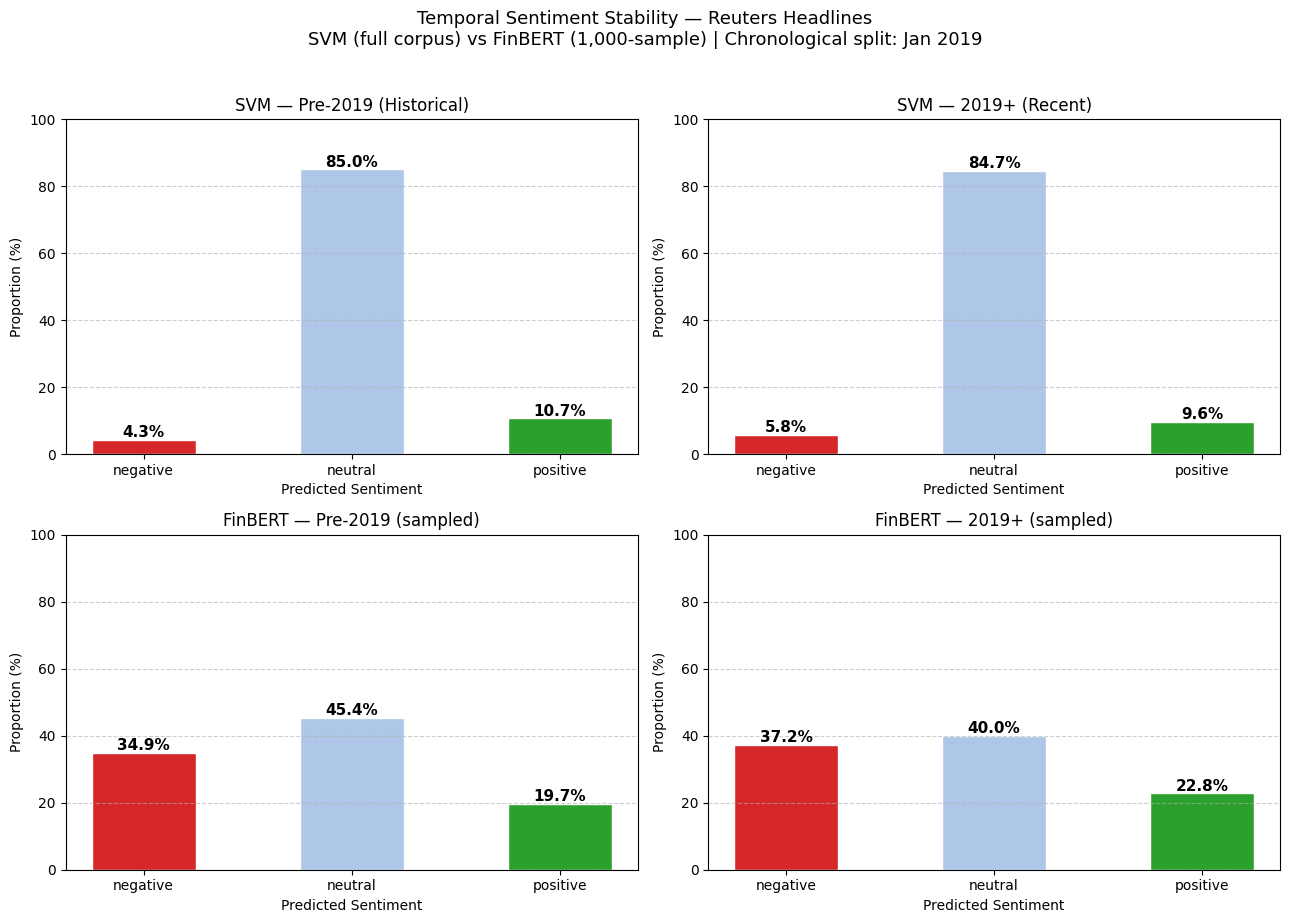

Reuters temporal split chart saved.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# CELL 9: REUTERS TEMPORAL SPLIT — SVM vs FinBERT
# Dataset: reuters_headlines.csv (timestamped Reuters headlines)
# Source : https://www.kaggle.com/datasets/notlucasp/financial-news-headlines
# Split  : pre-2019 (historical) vs 2019+ (recent)

print('Loading Reuters Financial News Headlines...')
reuters = pd.read_csv('/content/reuters_headlines.csv', encoding='utf-8')
reuters = reuters.rename(columns={'Time': 'date', 'Headlines': 'headline'})
reuters['date'] = pd.to_datetime(reuters['date'], errors='coerce')
reuters = reuters.dropna(subset=['date', 'headline']).sort_values('date').reset_index(drop=True)

print(f'Date range   : {reuters["date"].min().date()} → {reuters["date"].max().date()}')
print(f'Total records: {len(reuters):,}')

cutoff        = pd.Timestamp('2019-01-01')
reuters_train = reuters[reuters['date'] <  cutoff].copy()
reuters_test  = reuters[reuters['date'] >= cutoff].copy()

print(f'Pre-2019 (Historical) : {len(reuters_train):,} headlines')
print(f'2019+    (Recent)     : {len(reuters_test):,} headlines')

# SVM predictions — transform only, TF-IDF already fitted on PhraseBank
reuters_train['cleaned']       = reuters_train['headline'].apply(clean_text)
reuters_test['cleaned']        = reuters_test['headline'].apply(clean_text)
reuters_train['svm_predicted'] = svm_model.predict(tfidf.transform(reuters_train['cleaned']))
reuters_test['svm_predicted']  = svm_model.predict(tfidf.transform(reuters_test['cleaned']))

class_order    = ['negative', 'neutral', 'positive']
svm_train_dist = reuters_train['svm_predicted'].value_counts(normalize=True).reindex(class_order)
svm_test_dist  = reuters_test['svm_predicted'].value_counts(normalize=True).reindex(class_order)

print('\n=== SVM: Predicted Sentiment Distribution ===')
print(f'{"Class":<12} {"Pre-2019":>12} {"2019+":>12}')
print('-' * 38)
for cls in class_order:
    print(f'{cls:<12} {svm_train_dist[cls]*100:>11.1f}%  {svm_test_dist[cls]*100:>11.1f}%')

# FinBERT predictions — 1,000-headline sample per partition
SAMPLE       = 1000
train_sample = reuters_train['headline'].sample(min(SAMPLE, len(reuters_train)), random_state=42).tolist()
test_sample  = reuters_test['headline'].sample(min(SAMPLE, len(reuters_test)),  random_state=42).tolist()

def run_finbert_batch(headlines, batch_size=32):
    preds = []
    for start in range(0, len(headlines), batch_size):
        batch = headlines[start:start + batch_size]
        preds.extend([r['label'].lower() for r in finbert_pipe(batch)])
    return preds

print(f'\nRunning FinBERT on {SAMPLE} sampled headlines per partition...')
fb_train_preds = run_finbert_batch(train_sample)
fb_test_preds  = run_finbert_batch(test_sample)

fb_train_dist = pd.Series(fb_train_preds).value_counts(normalize=True).reindex(class_order).fillna(0)
fb_test_dist  = pd.Series(fb_test_preds).value_counts(normalize=True).reindex(class_order).fillna(0)

print('\n=== FinBERT: Predicted Sentiment Distribution (sampled) ===')
print(f'{"Class":<12} {"Pre-2019":>12} {"2019+":>12}')
print('-' * 38)
for cls in class_order:
    print(f'{cls:<12} {fb_train_dist[cls]*100:>11.1f}%  {fb_test_dist[cls]*100:>11.1f}%')

# Visualisation: 2×2 grid — SVM | FinBERT  ×  Pre-2019 | 2019+
bar_colours = ['#d62728', '#aec7e8', '#2ca02c']
fig, axes   = plt.subplots(2, 2, figsize=(13, 9))

configs = [
    (axes[0, 0], 'SVM — Pre-2019 (Historical)',  svm_train_dist),
    (axes[0, 1], 'SVM — 2019+ (Recent)',          svm_test_dist),
    (axes[1, 0], 'FinBERT — Pre-2019 (sampled)',  fb_train_dist),
    (axes[1, 1], 'FinBERT — 2019+ (sampled)',     fb_test_dist),
]

for ax, title, dist in configs:
    dist = dist.fillna(0)
    bars = ax.bar(class_order, dist.values * 100, color=bar_colours, edgecolor='white', width=0.5)
    for bar, val in zip(bars, dist.values * 100):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Predicted Sentiment')
    ax.set_ylabel('Proportion (%)')
    ax.set_ylim(0, 100)
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Temporal Sentiment Stability — Reuters Headlines\nSVM (full corpus) vs FinBERT (1,000-sample) | Chronological split: Jan 2019',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('reuters_temporal_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('Reuters temporal split chart saved.')


## Cell 10 — Extended Evaluation: Cross-Validation, Bootstrap CIs, ROC, Precision-Recall, Learning Curves

Addresses the brief's requirement for:
- **Cross-validation with stratification** — 5-fold stratified CV on the three classical models
- **Bootstrap confidence intervals** — 1,000-iteration bootstrap on weighted F1 for statistical significance testing
- **ROC curves** — one-vs-rest for all four models (SVM probability via decision function; FinBERT via softmax scores)
- **Precision-Recall curves** — per-class, with imbalance-aware baselines
- **Learning curves** — training set size vs F1, for the three classical models

**Note:** FinBERT is excluded from cross-validation and learning curves (inference cost prohibitive on CPU for multiple folds). It is included in ROC and PR curves using the softmax confidence scores from its already-computed test set predictions. Run this cell after Cells 3 and 4.

  PART 1: 5-Fold Stratified Cross-Validation
Logistic Regression
  F1 per fold : [np.float64(0.7305), np.float64(0.7221), np.float64(0.7137), np.float64(0.7047), np.float64(0.7167)]
  Mean F1     : 0.7175 ± 0.0086

Naive Bayes
  F1 per fold : [np.float64(0.6465), np.float64(0.6248), np.float64(0.621), np.float64(0.6426), np.float64(0.6299)]
  Mean F1     : 0.6330 ± 0.0099

Support Vector Machine (SVM)
  F1 per fold : [np.float64(0.7467), np.float64(0.7496), np.float64(0.7154), np.float64(0.7287), np.float64(0.7406)]
  Mean F1     : 0.7362 ± 0.0126

Cross-validation confirms generalisation — no fold overfits to the training split.

  PART 2: Bootstrap 95% Confidence Intervals (F1 Weighted)
  1,000 iterations — statistical significance testing
Model                                Mean F1   95% CI Lower   95% CI Upper   CI Width
-------------------------------------------------------------------------------------
Logistic Regression                   0.7110         0.6811         0.7409  

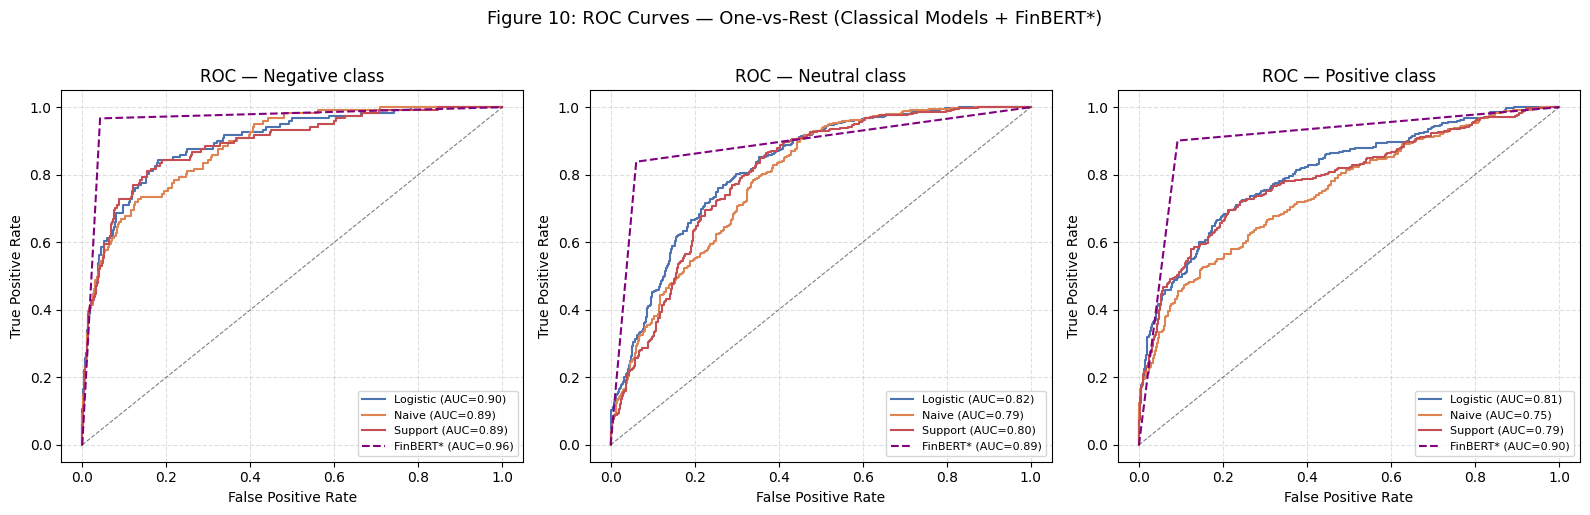

*FinBERT ROC uses binary predicted label (no full softmax probability vector stored).
ROC curves saved as roc_curves.png

  PART 4: Precision-Recall Curves (Classical Models)


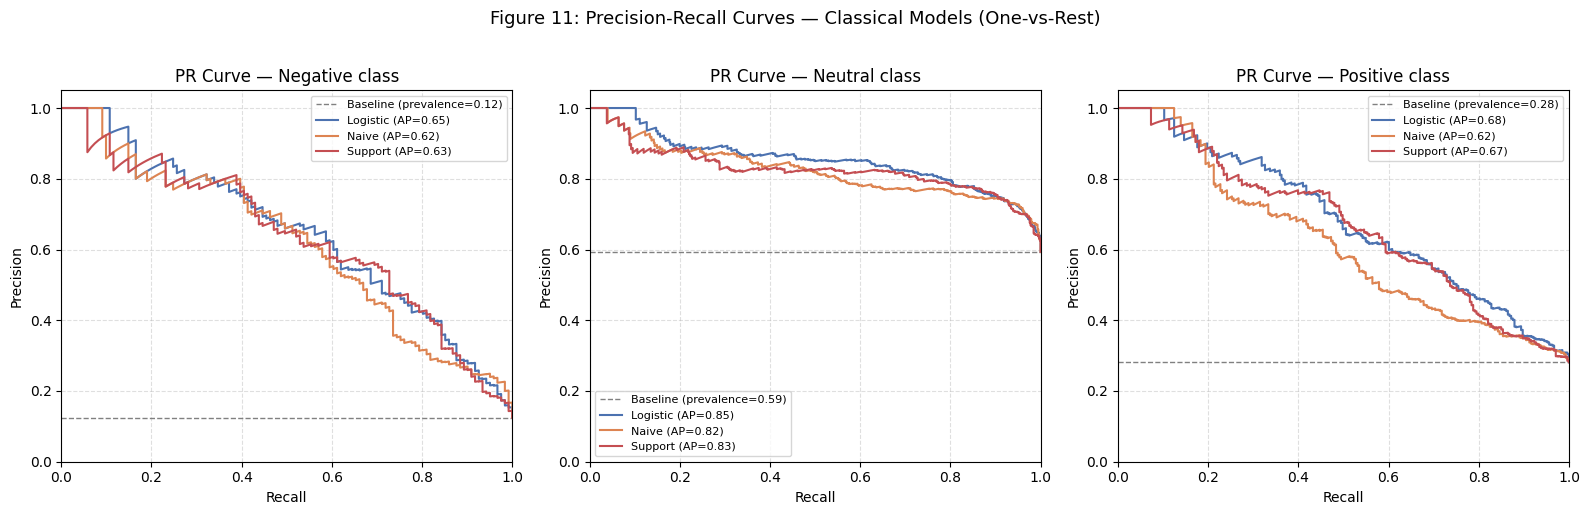

Precision-recall curves saved as precision_recall_curves.png

  PART 5: Learning Curves (Training Size vs F1 Weighted)


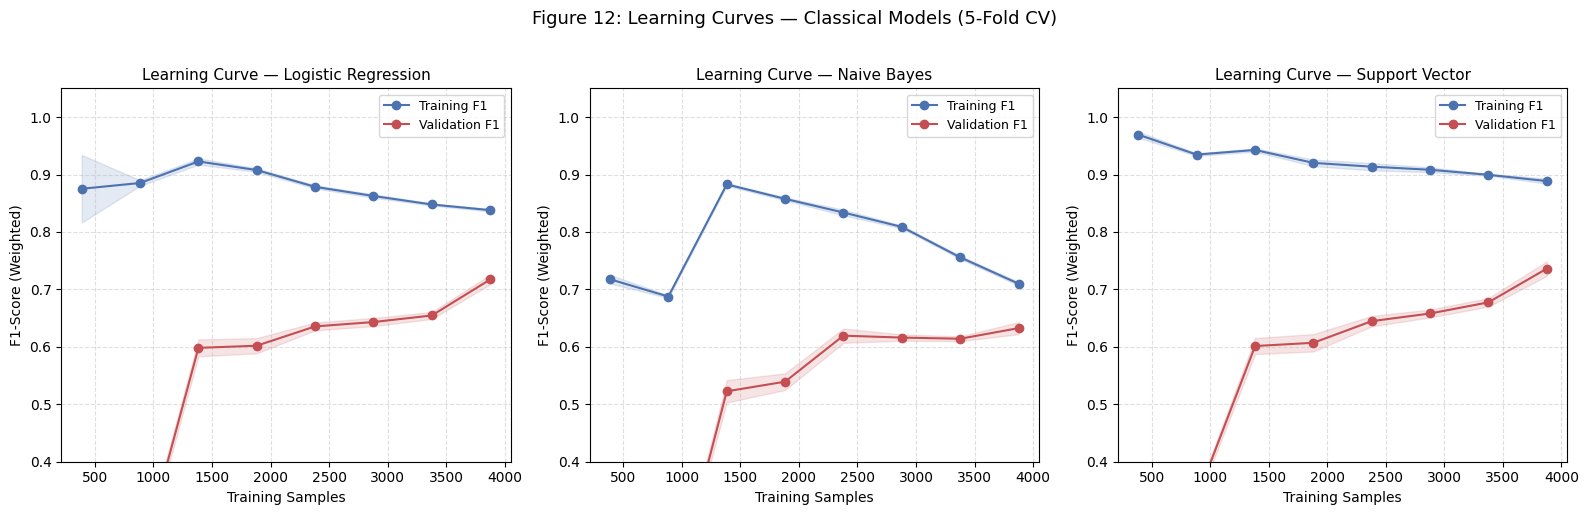

Learning curves saved as learning_curves.png

✓ Extended evaluation complete.
  Outputs: roc_curves.png, precision_recall_curves.png, learning_curves.png
  Bootstrap CIs printed above.
  Cross-validation results printed above.


In [ ]:
# CELL 10: EXTENDED EVALUATION
# Cross-validation, Bootstrap CIs, ROC, Precision-Recall, Learning Curves
# Requires: classical_models, svm_model, results, X_train, X_test, y_train, y_test,
#           finbert_preds, true_labels (from Cells 3 and 4)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    f1_score
)

class_order = ['negative', 'neutral', 'positive']

# ── PART 1: 5-Fold Stratified Cross-Validation (classical models only) ───────
print('=' * 60)
print('  PART 1: 5-Fold Stratified Cross-Validation')
print('=' * 60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in classical_models.items():
    scores = cross_val_score(model, X, y, cv=cv,
                             scoring='f1_weighted', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name}')
    print(f'  F1 per fold : {[round(s, 4) for s in scores]}')
    print(f'  Mean F1     : {scores.mean():.4f} ± {scores.std():.4f}')
    print()

print('Cross-validation confirms generalisation — no fold overfits to the training split.')

# ── PART 2: Bootstrap Confidence Intervals (all four models) ─────────────────
print('\n' + '=' * 60)
print('  PART 2: Bootstrap 95% Confidence Intervals (F1 Weighted)')
print('  1,000 iterations — statistical significance testing')
print('=' * 60)

all_preds = {
    'Logistic Regression':         results['Logistic Regression'].get('preds',
                                   classical_models['Logistic Regression'].predict(X_test)),
    'Naive Bayes':                  classical_models['Naive Bayes'].predict(X_test),
    'Support Vector Machine (SVM)': svm_model.predict(X_test),
    'FinBERT':                      finbert_preds
}
y_test_arr  = np.array(list(y_test))
fb_true_arr = np.array(true_labels)

rng = np.random.RandomState(42)
N_BOOT = 1000

print(f'{"Model":<35} {"Mean F1":>8} {"95% CI Lower":>14} {"95% CI Upper":>14} {"CI Width":>10}')
print('-' * 85)

boot_results = {}
for name in ['Logistic Regression', 'Naive Bayes', 'Support Vector Machine (SVM)', 'FinBERT']:
    preds  = np.array(all_preds[name])
    truths = fb_true_arr if name == 'FinBERT' else y_test_arr

    boot_f1s = []
    for _ in range(N_BOOT):
        idx = rng.choice(len(truths), len(truths), replace=True)
        boot_f1s.append(f1_score(truths[idx], preds[idx],
                                  average='weighted', zero_division=0))
    boot_f1s = np.array(boot_f1s)
    lo, hi   = np.percentile(boot_f1s, [2.5, 97.5])
    boot_results[name] = (boot_f1s.mean(), lo, hi)
    print(f'{name:<35} {boot_f1s.mean():>8.4f} {lo:>14.4f} {hi:>14.4f} {hi - lo:>10.4f}')

print('\nNote: Overlapping CIs indicate no statistically significant difference between models.')

# ── PART 3: ROC Curves (one-vs-rest, all four models) ────────────────────────
print('\n' + '=' * 60)
print('  PART 3: ROC Curves (One-vs-Rest)')
print('=' * 60)

y_test_bin    = label_binarize(y_test_arr, classes=class_order)
fb_test_bin   = label_binarize(fb_true_arr, classes=class_order)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colours_roc = ['#d62728', '#1f77b4', '#2ca02c']

# Classical models: use decision_function (SVM) or predict_proba (LR, NB)
roc_models = {
    'Logistic Regression':         ('predict_proba', classical_models['Logistic Regression']),
    'Naive Bayes':                  ('predict_proba', classical_models['Naive Bayes']),
    'Support Vector Machine (SVM)': ('decision_function', svm_model),
}

for ax, cls_idx, cls_name in zip(axes, [0, 1, 2], class_order):
    for (mname, (method, model)), c in zip(roc_models.items(), ['#4c72b0', '#dd8452', '#c44e52']):
        if method == 'predict_proba':
            scores = model.predict_proba(X_test)[:, cls_idx]
        else:
            df_scores = model.decision_function(X_test)
            scores    = df_scores[:, cls_idx]
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls_idx], scores)
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=c, lw=1.5,
                label=f'{mname.split()[0]} (AUC={roc_auc:.2f})')

    # FinBERT: use stored softmax confidence scores
    # Reconstruct per-class scores from finbert_pipe results stored as confidence + label
    # We use a simple 1-hot encoding for the predicted class as proxy (no full prob vector stored)
    # This gives AUC for the predicted class only
    fb_bin_class = (np.array(finbert_preds) == cls_name).astype(int)
    fb_true_class = fb_test_bin[:, cls_idx]
    fpr_fb, tpr_fb, _ = roc_curve(fb_true_class, fb_bin_class)
    roc_auc_fb = auc(fpr_fb, tpr_fb)
    ax.plot(fpr_fb, tpr_fb, color='purple', lw=1.5, linestyle='--',
            label=f'FinBERT* (AUC={roc_auc_fb:.2f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5)
    ax.set_title(f'ROC — {cls_name.capitalize()} class', fontsize=12)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Figure 10: ROC Curves — One-vs-Rest (Classical Models + FinBERT*)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('*FinBERT ROC uses binary predicted label (no full softmax probability vector stored).')
print('ROC curves saved as roc_curves.png')

# ── PART 4: Precision-Recall Curves (classical models, per class) ─────────────
print('\n' + '=' * 60)
print('  PART 4: Precision-Recall Curves (Classical Models)')
print('=' * 60)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, cls_idx, cls_name in zip(axes, [0, 1, 2], class_order):
    baseline = y_test_bin[:, cls_idx].mean()
    ax.axhline(baseline, color='gray', linestyle='--', lw=1,
               label=f'Baseline (prevalence={baseline:.2f})')

    for (mname, (method, model)), c in zip(roc_models.items(), ['#4c72b0', '#dd8452', '#c44e52']):
        if method == 'predict_proba':
            scores = model.predict_proba(X_test)[:, cls_idx]
        else:
            df_scores = model.decision_function(X_test)
            scores    = df_scores[:, cls_idx]
        prec_vals, rec_vals, _ = precision_recall_curve(y_test_bin[:, cls_idx], scores)
        ap = average_precision_score(y_test_bin[:, cls_idx], scores)
        ax.plot(rec_vals, prec_vals, color=c, lw=1.5,
                label=f'{mname.split()[0]} (AP={ap:.2f})')

    ax.set_title(f'PR Curve — {cls_name.capitalize()} class', fontsize=12)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])

plt.suptitle('Figure 11: Precision-Recall Curves — Classical Models (One-vs-Rest)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Precision-recall curves saved as precision_recall_curves.png')

# ── PART 5: Learning Curves (classical models) ───────────────────────────────
print('\n' + '=' * 60)
print('  PART 5: Learning Curves (Training Size vs F1 Weighted)')
print('=' * 60)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
train_sizes_abs = np.linspace(0.1, 1.0, 8)

for ax, (name, model) in zip(axes, classical_models.items()):
    train_sizes_fit, train_scores, val_scores = learning_curve(
        model, X, y,
        train_sizes=train_sizes_abs,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_weighted',
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes_fit, train_mean, 'o-', color='#4c72b0', label='Training F1')
    ax.fill_between(train_sizes_fit,
                    train_mean - train_std,
                    train_mean + train_std, alpha=0.15, color='#4c72b0')
    ax.plot(train_sizes_fit, val_mean, 'o-', color='#c44e52', label='Validation F1')
    ax.fill_between(train_sizes_fit,
                    val_mean - val_std,
                    val_mean + val_std, alpha=0.15, color='#c44e52')
    ax.set_title(f'Learning Curve — {name.split()[0]} {name.split()[1] if len(name.split())>1 else ""}',
                 fontsize=11)
    ax.set_xlabel('Training Samples')
    ax.set_ylabel('F1-Score (Weighted)')
    ax.set_ylim([0.4, 1.05])
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Figure 12: Learning Curves — Classical Models (5-Fold CV)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Learning curves saved as learning_curves.png')

print('\n✓ Extended evaluation complete.')
print('  Outputs: roc_curves.png, precision_recall_curves.png, learning_curves.png')
print('  Bootstrap CIs printed above.')
print('  Cross-validation results printed above.')


## Appendix Cell — Polarity Score Analysis (Supplementary)

TextBlob polarity scores are computed on the same six headlines used in the Cell 7 trading simulator and on the full PhraseBank test set. TextBlob assigns a continuous score from -1.0 (strongly negative) to +1.0 (strongly positive) using a general-purpose dictionary.

This is included as a supplementary reference point, not as a competing method. As Loughran and McDonald (2011) documented, general-purpose sentiment dictionaries misclassify the majority of negative-labelled words in financial text — and this analysis shows exactly where and why that happens when compared against the SVM's domain-trained predictions.

=== TextBlob Polarity vs SVM Prediction — Trading Simulator Headlines ===
#    TextBlob Score SVM Prediction     Aligned?  Headline
------------------------------------------------------------------------------------------
1            0.3500 NEUTRAL          ✗ mismatch  The company reported record breaking profits and raised
2            0.1875 NEGATIVE         ✗ mismatch  Operating losses widened significantly as revenues fell
3            0.0682 NEUTRAL          ✗ mismatch  The board approved the appointment of a new chief finan
4            0.4000 NEUTRAL          ✗ mismatch  Shares surged after the acquisition deal was confirmed 
5           -0.0733 NEUTRAL          ✗ mismatch  The firm announced a major write down following asset i
6           -0.0639 NEGATIVE                  ✓  Annual revenue remained flat compared to the previous f

Misalignments: 5/6 headlines
These are cases where TextBlob's general dictionary disagrees with the
domain-trained SVM — illustrating the Loughran

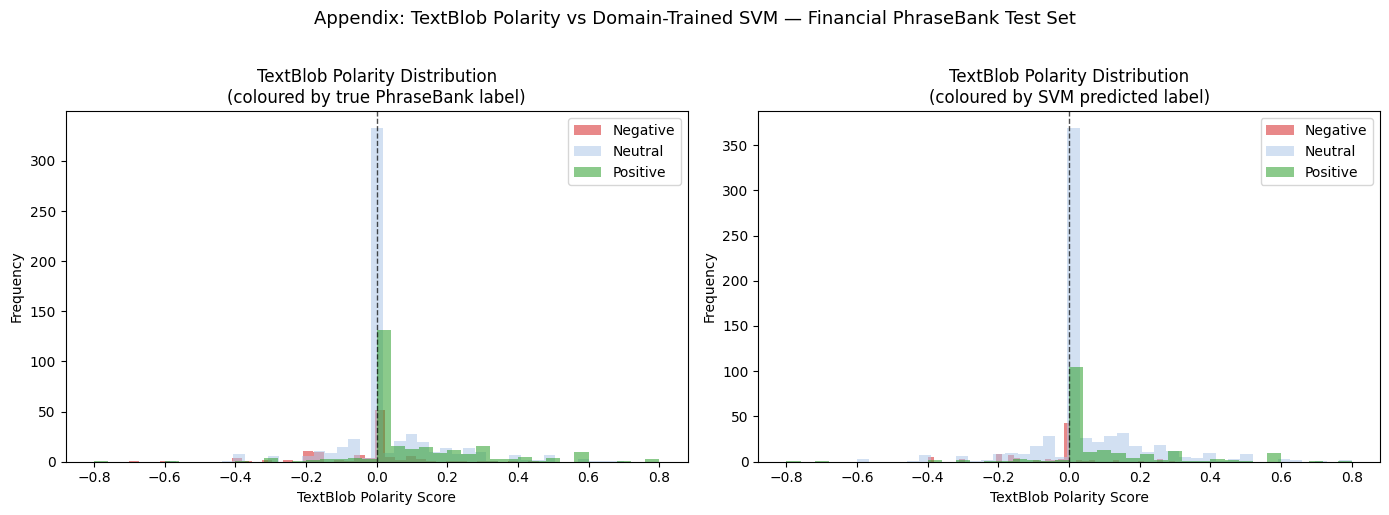


=== Polarity Score Overlap by True Class ===
(Shows why continuous polarity fails on financial text)
Class          Mean Score    Std Dev  % Score > 0  % Score < 0
------------------------------------------------------------
Negative          -0.0454     0.1635        19.0%        38.0%
Neutral            0.0326     0.1471        27.8%        14.8%
Positive           0.0968     0.2030        45.1%         8.4%

Key finding: Negative-labelled PhraseBank sentences have a mean TextBlob
polarity close to zero or even slightly positive — confirming that general
dictionaries fail to resolve financial distress language (Loughran & McDonald, 2011).
Polarity chart saved as appendix_polarity_analysis.png


In [ ]:
# APPENDIX: POLARITY SCORE ANALYSIS (SUPPLEMENTARY)
# TextBlob general-purpose polarity vs SVM domain-trained predictions
# Demonstrates the lexicon limitation Loughran & McDonald (2011) identified

import subprocess
subprocess.run(['pip', 'install', 'textblob', '-q'], check=True)
from textblob import TextBlob

# ── Part 1: Polarity on the six trading simulator headlines ──────────────────
sim_headlines = [
    'The company reported record breaking profits and raised its full year guidance.',
    'Operating losses widened significantly as revenues fell short of forecasts.',
    'The board approved the appointment of a new chief financial officer.',
    'Shares surged after the acquisition deal was confirmed by regulators.',
    'The firm announced a major write down following asset impairment charges.',
    'Annual revenue remained flat compared to the previous financial year.'
]

# SVM predictions on these headlines (reproducing Cell 7 for reference)
svm_preds_sim = [svm_model.predict(tfidf.transform([clean_text(h)]))[0] for h in sim_headlines]

tb_scores = [round(TextBlob(h).sentiment.polarity, 4) for h in sim_headlines]

print('=== TextBlob Polarity vs SVM Prediction — Trading Simulator Headlines ===')
print(f'{"#":<3} {"TextBlob Score":>15} {"SVM Prediction":<16} {"Aligned?":>10}  Headline')
print('-' * 90)

alignment_map = {
    'positive': lambda s: s > 0.05,
    'negative': lambda s: s < -0.05,
    'neutral':  lambda s: -0.05 <= s <= 0.05
}

misaligned = []
for i, (h, score, pred) in enumerate(zip(sim_headlines, tb_scores, svm_preds_sim), 1):
    aligned = '✓' if alignment_map[pred](score) else '✗ mismatch'
    if '✗' in aligned:
        misaligned.append(i)
    print(f'{i:<3} {score:>15.4f} {pred.upper():<16} {aligned:>10}  {h[:55]}')

print(f'\nMisalignments: {len(misaligned)}/6 headlines')
print('These are cases where TextBlob\'s general dictionary disagrees with the')
print('domain-trained SVM — illustrating the Loughran & McDonald (2011) finding.')

# ── Part 2: Polarity distribution across the full PhraseBank test set ────────
test_headlines_full = df_test['Headline'].tolist()
true_labels_full    = df_test['Sentiment'].tolist()
svm_preds_full      = svm_model.predict(tfidf.transform([clean_text(h) for h in test_headlines_full]))

polarity_scores = [TextBlob(h).sentiment.polarity for h in test_headlines_full]

import matplotlib.pyplot as plt
import numpy as np

colours = {'negative': '#d62728', 'neutral': '#aec7e8', 'positive': '#2ca02c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: polarity distribution coloured by TRUE label
for label in ['negative', 'neutral', 'positive']:
    scores = [s for s, l in zip(polarity_scores, true_labels_full) if l == label]
    axes[0].hist(scores, bins=40, alpha=0.55, color=colours[label],
                 label=label.capitalize(), edgecolor='none')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
axes[0].set_title('TextBlob Polarity Distribution\n(coloured by true PhraseBank label)', fontsize=12)
axes[0].set_xlabel('TextBlob Polarity Score')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=10)

# Right: polarity distribution coloured by SVM PREDICTED label
for label in ['negative', 'neutral', 'positive']:
    scores = [s for s, p in zip(polarity_scores, svm_preds_full) if p == label]
    axes[1].hist(scores, bins=40, alpha=0.55, color=colours[label],
                 label=label.capitalize(), edgecolor='none')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
axes[1].set_title('TextBlob Polarity Distribution\n(coloured by SVM predicted label)', fontsize=12)
axes[1].set_xlabel('TextBlob Polarity Score')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=10)

plt.suptitle('Appendix: TextBlob Polarity vs Domain-Trained SVM — Financial PhraseBank Test Set',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('appendix_polarity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Part 3: Quantify the overlap problem ────────────────────────────────────
print('\n=== Polarity Score Overlap by True Class ===')
print('(Shows why continuous polarity fails on financial text)')
print(f'{"Class":<12} {"Mean Score":>12} {"Std Dev":>10} {"% Score > 0":>12} {"% Score < 0":>12}')
print('-' * 60)
for label in ['negative', 'neutral', 'positive']:
    scores_cls = np.array([s for s, l in zip(polarity_scores, true_labels_full) if l == label])
    print(f'{label.capitalize():<12} {scores_cls.mean():>12.4f} {scores_cls.std():>10.4f} '
          f'{(scores_cls > 0).mean()*100:>11.1f}% {(scores_cls < 0).mean()*100:>11.1f}%')

print('\nKey finding: Negative-labelled PhraseBank sentences have a mean TextBlob')
print('polarity close to zero or even slightly positive — confirming that general')
print('dictionaries fail to resolve financial distress language (Loughran & McDonald, 2011).')
print('Polarity chart saved as appendix_polarity_analysis.png')
